
----------------------------------------
Hidden Layers: [8]
Activation: relu
----------------------------------------
Test Accuracy: 0.9667
Test Loss: 0.1644

----------------------------------------
Hidden Layers: [8]
Activation: tanh
----------------------------------------
Test Accuracy: 0.9667
Test Loss: 0.1978

----------------------------------------
Hidden Layers: [8]
Activation: sigmoid
----------------------------------------
Test Accuracy: 0.9333
Test Loss: 0.4468

----------------------------------------
Hidden Layers: [16, 8]
Activation: relu
----------------------------------------
Test Accuracy: 0.9667
Test Loss: 0.2274

----------------------------------------
Hidden Layers: [16, 8]
Activation: tanh
----------------------------------------
Test Accuracy: 0.9667
Test Loss: 0.0778

----------------------------------------
Hidden Layers: [16, 8]
Activation: sigmoid
----------------------------------------
Test Accuracy: 0.9
Test Loss: 0.4591

------------------------------

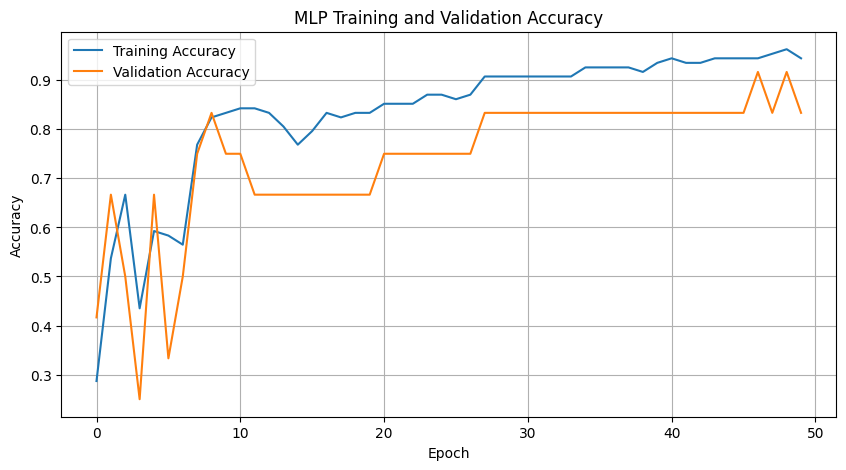

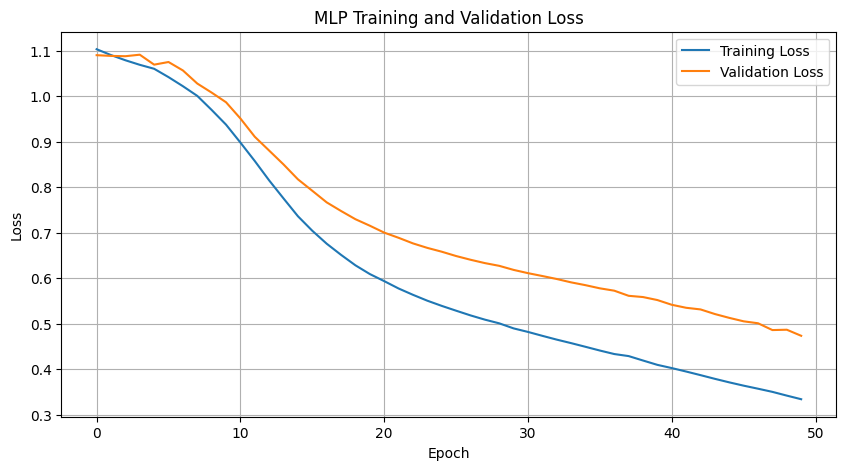


NEW IRIS FLOWER PREDICTION
----------------------------------------
Sepal Length: 5.1
Sepal Width : 3.5
Petal Length: 1.4
Petal Width : 0.2

Predicted Iris Species: setosa


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input


# Load Iris dataset
iris = load_iris()

X = iris.data
y = iris.target.reshape(-1, 1)

classes = iris.target_names


# One-hot encoding
encoder = OneHotEncoder(sparse_output=False)
y_encoded = encoder.fit_transform(y)


# Standardize input features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.2,
    random_state=42
)


# Function to create MLP
def create_mlp(input_dim, output_dim, hidden_layers, activation):

    model = Sequential()

    model.add(Input(shape=(input_dim,)))

    for units in hidden_layers:
        model.add(Dense(units, activation=activation))

    model.add(Dense(output_dim, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


# Different hidden layer configurations
hidden_layer_configs = [
    [8],
    [16, 8],
    [32, 16, 8]
]


# Different activation functions
activations = [
    'relu',
    'tanh',
    'sigmoid'
]


results = []
last_model = None
last_history = None


# Train and evaluate different MLP configurations
for hidden_layers in hidden_layer_configs:

    for activation in activations:

        print("\n----------------------------------------")
        print("Hidden Layers:", hidden_layers)
        print("Activation:", activation)
        print("----------------------------------------")

        model = create_mlp(
            input_dim=4,
            output_dim=3,
            hidden_layers=hidden_layers,
            activation=activation
        )

        history = model.fit(
            X_train,
            y_train,
            epochs=50,
            batch_size=5,
            verbose=0,
            validation_split=0.1
        )

        test_loss, test_acc = model.evaluate(
            X_test,
            y_test,
            verbose=0
        )

        print("Test Accuracy:", round(test_acc, 4))
        print("Test Loss:", round(test_loss, 4))

        results.append([
            hidden_layers,
            activation,
            test_acc,
            test_loss
        ])

        last_model = model
        last_history = history


# Display results
print("\n\nMLP PERFORMANCE RESULTS")
print("----------------------------------------")

for result in results:
    print(
        "Hidden Layers:", result[0],
        "| Activation:", result[1],
        "| Accuracy:", round(result[2], 4),
        "| Loss:", round(result[3], 4)
    )


# Plot accuracy
plt.figure(figsize=(10, 5))

plt.plot(
    last_history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    last_history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('MLP Training and Validation Accuracy')
plt.legend()
plt.grid(True)

plt.show()


# Plot loss
plt.figure(figsize=(10, 5))

plt.plot(
    last_history.history['loss'],
    label='Training Loss'
)

plt.plot(
    last_history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('MLP Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.show()


# New Iris flower prediction
sepal_length = 5.1
sepal_width = 3.5
petal_length = 1.4
petal_width = 0.2

user_input = np.array([
    [sepal_length, sepal_width, petal_length, petal_width]
])


# Scale the new input
user_input_scaled = scaler.transform(user_input)


# Predict using the last trained model
prediction = last_model.predict(
    user_input_scaled,
    verbose=0
)


predicted_class_index = np.argmax(prediction)
predicted_class_name = classes[predicted_class_index]


print("\nNEW IRIS FLOWER PREDICTION")
print("----------------------------------------")
print("Sepal Length:", sepal_length)
print("Sepal Width :", sepal_width)
print("Petal Length:", petal_length)
print("Petal Width :", petal_width)

print("\nPredicted Iris Species:", predicted_class_name)